In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.base import clone

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

warnings.filterwarnings("ignore", category=RuntimeWarning, module="statsmodels")

RANDOM_STATE = 42

In [81]:
df = pd.read_csv("Ukraine_commercial_ML.csv")

In [82]:
# Локацію (район/місто) кодуємо простим one-hot -- ті самі колонки city_*,
# що вже прийшли з preprocessing_commercial.ipynb. Без реконструкції сирої категорії
# і без target encoding: так само, як зроблено для квартир -- простіше, без ризику
# витоку через таргет, і кожна категорія лишається окремою прозорою ознакою.
print([c for c in df.columns if c.startswith("city_")])

['city_Chernihiv', 'city_Chernivtsi', 'city_Dnipro', 'city_Ivano-Frankivsk', 'city_Kharkiv', 'city_Khmelnytskyi', 'city_Kropyvnytskyi', 'city_Lutsk', 'city_Lviv', 'city_Mykolaiv', 'city_Odesa', 'city_Poltava', 'city_Rivne', 'city_Sumy', 'city_Ternopil', 'city_Uzhhorod', 'city_Vinnytsia', 'city_Zaporizhzhia', 'city_Zhytomyr']


In [83]:
def object_group(df: pd.DataFrame) -> pd.Series:
    """Той самий поділ на типи об'єктів, що й у preprocessing_commercial.ipynb:
    приміщення / гараж+паркомісце / склад. Для кожного типу тренуємо ОКРЕМУ модель,
    бо ціноутворення в них принципово різне (наприклад площа паркомісця майже
    не варіюється, а ціна складу залежить від зовсім інших ознак, ніж офісу)."""
    is_parking = df["is_garage"].astype(bool) | df["is_parking_spot"].astype(bool)
    is_warehouse = df["is_warehouse"].astype(bool)
    return pd.Series(
        np.select([is_parking, is_warehouse], ["parking_or_garage", "warehouse"], default="premises"),
        index=df.index,
    )


groups = object_group(df)
SEGMENT_NAMES = ["premises", "parking_or_garage", "warehouse"]
segments = {seg: df[groups == seg].reset_index(drop=True) for seg in SEGMENT_NAMES}
for seg, seg_df in segments.items():
    print(seg, seg_df.shape)

premises (484, 69)
parking_or_garage (263, 69)
warehouse (697, 69)


In [84]:
TARGET = "price"
MISSING_COLS = ["ceiling_height", "year_of_building", "poi_distance_m", "rental_price", "implied_yield", "floor_count"]


def select_stable_columns(X: pd.DataFrame, min_count: int = 5) -> list[str]:
    """Ознаки, які реально мають варіацію в ЦЬОМУ КОНКРЕТНОМУ наборі (train-спліт
    чи CV-фолд): прибирає константи і майже-константні бінарні (0/1) ознаки, де
    рідший клас представлений менше ніж `min_count` разів. Рахується строго на
    переданому X, а не на всьому сегменті -- інакше ознака з нормальною варіацією
    по всьому сегменту (напр. house_type_* чи has_autonomous_heating для гаражів)
    може випадково стати константою всередині конкретного спліту й зламати
    HistGradientBoosting -- його біннінг вимагає щонайменше 2 різних значення
    на ознаку."""
    keep, dropped = [], []
    for c in X.columns:
        vals = X[c].dropna()
        nun = vals.nunique()
        if nun <= 1:
            dropped.append(c)
            continue
        if nun == 2 and set(vals.unique()) <= {0, 1}:
            minority = vals.value_counts().min()
            if minority < min_count:
                dropped.append(c)
                continue
        keep.append(c)
    if dropped:
        print(f"  Прибрано {len(dropped)} констант/малодисперсних ознак у цьому спліті: {dropped}")
    return keep


def build_feature_frames(df: pd.DataFrame):
    """Ціль -- ЗАГАЛЬНА ціна об'єкта (price), а не ціна за м². 'price' виключена з X.
    Локація вже закодована one-hot колонками (district_*/city_*) з препроцесингу.
    Повертає (X_raw, X_imputed, y). Відбір стабільних колонок робиться ПІЗНІШЕ,
    вже на конкретному train-спліті/фолді (див. select_stable_columns) --
    рахувати його тут, на всьому сегменті одразу, недостатньо надійно."""
    feature_cols = [c for c in df.columns if c != TARGET]
    X_raw = df[feature_cols].astype({c: "float64" for c in df[feature_cols].select_dtypes("bool").columns})

    X_imputed = X_raw.copy()
    for col in MISSING_COLS:
        if col in X_imputed.columns:
            flag_col = f"{col}_missing"
            X_imputed[flag_col] = X_imputed[col].isna().astype(int)
            X_raw[flag_col] = X_imputed[flag_col]
            median_val = X_imputed[col].median()
            if pd.isna(median_val):
                # у цьому сегменті колонка на 100% пуста (напр. rental_price
                # для гаражів/паркомісць -- там просто немає орендарів) --
                # медіана теж NaN, тому підстраховуємось нулем.
                median_val = 0.0
            X_imputed[col] = X_imputed[col].fillna(median_val)

    y = np.log1p(df[TARGET])
    return X_raw, X_imputed, y

In [85]:
def drop_constant_columns(X: pd.DataFrame) -> pd.DataFrame:
    constant_cols = [c for c in X.columns if X[c].nunique(dropna=False) <= 1]
    if constant_cols:
        print(f"  Прибрано {len(constant_cols)} константних колонок: {constant_cols}")
    return X.drop(columns=constant_cols)


def prune_by_vif(X: pd.DataFrame, thresh: float = 10.0) -> list[str]:
    X = drop_constant_columns(X).astype(float)
    X_const = add_constant(X, has_constant="add")

    while X_const.shape[1] > 2:
        vifs = pd.Series(
            [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])],
            index=X_const.columns,
        ).drop("const")
        worst = vifs.idxmax()
        if vifs[worst] < thresh:
            break
        print(f"  Дропаю '{worst}' (VIF={vifs[worst]:.1f})")
        X_const = X_const.drop(columns=[worst])

    kept = [c for c in X_const.columns if c != "const"]
    print(f"  Лишилось {len(kept)} ознак після VIF-відбору")
    return kept


def evaluate(y_true_log: np.ndarray, y_pred_log: np.ndarray) -> dict:
    """Модель оптимізується на log(price); метрики рахуємо як на
    лог-шкалі (R2), так і у відновлених доларах на весь об'єкт (MAE/RMSE/MAPE)."""
    price_true = np.expm1(y_true_log)
    price_pred = np.expm1(y_pred_log)
    return {
        "R2": r2_score(y_true_log, y_pred_log),
        "MAE_$": mean_absolute_error(price_true, price_pred),
        "RMSE_$": mean_squared_error(price_true, price_pred) ** 0.5,
        "MAPE_%": (np.abs((price_true - price_pred) / price_true).mean()) * 100,
    }


RF_GRID = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 8, 12, 20],
    "min_samples_leaf": [1, 2, 4],
}
HGB_GRID = {
    "max_iter": [200, 400, 600],
    "max_depth": [None, 4, 8],
    "learning_rate": [0.03, 0.06, 0.1],
}


def fit_variant(model_name, Xr_train, Xr_test, Xi_train, Xi_test, y_train, y_test, cols, fixed_params=None):
    """Навчає одну з трьох моделей на заданому підмножині колонок `cols`.
    Якщо fixed_params задано -- не робить GridSearchCV, а просто ставить ці
    гіперпараметри (використовується у крос-валідації нижче, де
    перетюнювати на кожному фолді занадто дорого)."""
    Xr_train_c, Xr_test_c = Xr_train[cols], Xr_test[cols]
    Xi_train_c, Xi_test_c = Xi_train[cols], Xi_test[cols]

    if model_name == "Ridge":
        scaler = StandardScaler()
        Xs_train_c = scaler.fit_transform(Xi_train_c)
        Xs_test_c = scaler.transform(Xi_test_c)
        if fixed_params is not None:
            model = RidgeCV(alphas=[fixed_params["alpha_"]]).fit(Xs_train_c, y_train)
        else:
            model = RidgeCV(alphas=np.logspace(-2, 3, 30)).fit(Xs_train_c, y_train)
        X_test_final = Xs_test_c

    elif model_name == "RandomForest":
        if fixed_params is not None:
            model = RandomForestRegressor(random_state=RANDOM_STATE, **fixed_params).fit(Xi_train_c, y_train)
        else:
            search = GridSearchCV(
                RandomForestRegressor(random_state=RANDOM_STATE),
                RF_GRID, cv=5, scoring="r2", n_jobs=-1,
            )
            search.fit(Xi_train_c, y_train)
            model = search.best_estimator_
        X_test_final = Xi_test_c

    else:  # HistGradientBoosting -- працює напряму з NaN
        if fixed_params is not None:
            model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **fixed_params).fit(Xr_train_c, y_train)
        else:
            search = GridSearchCV(
                HistGradientBoostingRegressor(random_state=RANDOM_STATE),
                HGB_GRID, cv=5, scoring="r2", n_jobs=-1,
            )
            search.fit(Xr_train_c, y_train)
            model = search.best_estimator_
        X_test_final = Xr_test_c

    metrics = evaluate(y_test.values, model.predict(X_test_final))
    return model, X_test_final, metrics


def get_model_params(model_name: str, model) -> dict:
    """Гіперпараметри переможця -- щоб зафіксувати їх для крос-валідації
    (там ми не перетюнюємо на кожному фолді, це занадто дорого)."""
    if model_name == "Ridge":
        return {"alpha_": model.alpha_}
    if model_name == "RandomForest":
        return {k: v for k, v in model.get_params().items()
                if k in ("n_estimators", "max_depth", "min_samples_leaf")}
    return {k: v for k, v in model.get_params().items()
            if k in ("max_iter", "max_depth", "learning_rate")}

In [86]:
def train_and_compare(df_segment: pd.DataFrame, segment_name: str, vif_thresh: float = 10.0):
    print(f"\n{'='*60}\n{segment_name}\n{'='*60}")

    X_raw, X_imputed, y = build_feature_frames(df_segment)
    idx_train, idx_test = train_test_split(
        df_segment.index, test_size=0.2, random_state=RANDOM_STATE
    )

    Xr_train, Xr_test = X_raw.loc[idx_train].copy(), X_raw.loc[idx_test].copy()
    Xi_train, Xi_test = X_imputed.loc[idx_train].copy(), X_imputed.loc[idx_test].copy()
    y_train, y_test = y.loc[idx_train], y.loc[idx_test]

    full_cols = select_stable_columns(Xi_train)

    print("--- Навчання на ПОВНОМУ наборі ознак (без VIF) ---")
    results, fitted = {}, {}
    for name in ["Ridge", "RandomForest", "HistGradientBoosting"]:
        model, X_test_final, metrics = fit_variant(
            name, Xr_train, Xr_test, Xi_train, Xi_test, y_train, y_test, full_cols
        )
        results[name] = metrics
        fitted[name] = model

    results_df = pd.DataFrame(results).T
    print("\n--- Результати на test (повний набір ознак) ---")
    print(results_df)

    # Обираємо модель за MAPE_% (% похибка на ціні об'єкта), а не за R² --
    # мета проєкту це оцінка вартості КОНКРЕТНОГО об'єкта, тож нам важлива
    # відносна точність по всьому діапазону цін, а не пояснена дисперсія
    # log(price). R² лишаємо в таблиці лише для довідки/діагностики.
    best_name = results_df["MAPE_%"].idxmin()
    print(f"\n>>> Найкраща модель (за мінімальним MAPE_%): {best_name}")

    print("\n--- VIF-відбір (лише для feature importance, на train) ---")
    kept_cols = prune_by_vif(Xi_train[full_cols], thresh=vif_thresh)

    best_model_pruned, X_test_pruned, pruned_metrics = fit_variant(
        best_name, Xr_train, Xr_test, Xi_train, Xi_test, y_train, y_test, kept_cols
    )
    print(f"\nMAPE_% {best_name}: повний набір ознак = {results_df.loc[best_name, 'MAPE_%']:.1f}%, "
          f"після VIF-відбору = {pruned_metrics['MAPE_%']:.1f}% "
          f"(R²: {results_df.loc[best_name, 'R2']:.3f} -> {pruned_metrics['R2']:.3f})")

    perm = permutation_importance(
        best_model_pruned, X_test_pruned, y_test, n_repeats=20,
        random_state=RANDOM_STATE, scoring="r2", n_jobs=-1,
    )
    importance_df = (
        pd.DataFrame({"feature": kept_cols, "importance": perm.importances_mean,
                      "std": perm.importances_std})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )

    top_n = importance_df.head(15)
    plt.figure(figsize=(8, 6))
    plt.barh(top_n["feature"][::-1], top_n["importance"][::-1], xerr=top_n["std"][::-1])
    plt.xlabel("Permutation importance (спад R² при перемішуванні ознаки)")
    plt.title(f"{segment_name} -- {best_name} (після VIF) -- топ ознак, ціль = ціна об'єкта, $")
    plt.tight_layout()
    plt.show()

    return {
        "results_df": results_df,
        "best_name": best_name,
        "best_model_pruned": best_model_pruned,
        "fixed_params": get_model_params(best_name, best_model_pruned),
        "importance_df": importance_df,
        "kept_cols": kept_cols,
    }

In [87]:
def cross_validate_best(df_segment: pd.DataFrame, best_name: str, kept_cols: list[str],
                         fixed_params: dict, n_splits: int = 5):
    X_raw, X_imputed, y = build_feature_frames(df_segment)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    fold_metrics = []

    for fold_i, (tr_idx, val_idx) in enumerate(kf.split(df_segment.index), start=1):
        idx_tr = df_segment.index[tr_idx]
        idx_val = df_segment.index[val_idx]

        Xr_tr, Xr_val = X_raw.loc[idx_tr].copy(), X_raw.loc[idx_val].copy()
        Xi_tr, Xi_val = X_imputed.loc[idx_tr].copy(), X_imputed.loc[idx_val].copy()
        y_tr, y_val = y.loc[idx_tr], y.loc[idx_val]

        cols = [c for c in kept_cols if c in Xi_tr.columns]
        cols = select_stable_columns(Xi_tr[cols])
        _, _, metrics = fit_variant(
            best_name, Xr_tr, Xr_val, Xi_tr, Xi_val, y_tr, y_val, cols, fixed_params=fixed_params
        )
        metrics["fold"] = fold_i
        fold_metrics.append(metrics)

    cv_df = pd.DataFrame(fold_metrics).set_index("fold")
    summary = cv_df.agg(["mean", "std"])
    print(cv_df)
    print("\n--- Підсумок по фолдах ---")
    print(summary)
    return cv_df

In [88]:
def save_production_pipeline(df_segment: pd.DataFrame, best_name: str, kept_cols: list[str],
                             fixed_params: dict, out_file: str):
    X_raw, X_imputed, y = build_feature_frames(df_segment)

    cols = [c for c in kept_cols if c in X_imputed.columns]
    cols = select_stable_columns(X_imputed[cols])
    Xi_c = X_imputed[cols]
    Xr_c = X_raw[cols]

    scaler = None
    if best_name == "Ridge":
        scaler = StandardScaler().fit(Xi_c)
        model = RidgeCV(alphas=[fixed_params["alpha_"]]).fit(scaler.transform(Xi_c), y)
    elif best_name == "RandomForest":
        model = RandomForestRegressor(random_state=RANDOM_STATE, **fixed_params).fit(Xi_c, y)
    else:
        model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **fixed_params).fit(Xr_c, y)

    median_fill = {col: X_imputed[col].median() for col in MISSING_COLS if col in X_imputed.columns}

    artifact = {
        "model_name": best_name,
        "model": model,
        "scaler": scaler,
        "feature_cols": cols,
        "missing_cols": MISSING_COLS,
        "median_fill": median_fill,
    }
    joblib.dump(artifact, out_file)
    print(f"Збережено: {out_file}")
    return artifact


def predict_new_object(artifact: dict, new_row: dict) -> float:
    """new_row -- звичайний dict з сирими значеннями ознак (як у вихідному df
    ПІСЛЯ one-hot кодування локації, напр. з колонками district_Pecherskyi=1 тощо)
    і 'area'. Повертає прогнозовану ЗАГАЛЬНУ ціну об'єкта в $."""
    row = pd.Series(new_row)

    for col in artifact["missing_cols"]:
        if col in artifact["feature_cols"] and (col not in row or pd.isna(row.get(col))):
            row[col] = artifact["median_fill"].get(col, 0)
        flag_col = f"{col}_missing"
        if flag_col in artifact["feature_cols"]:
            row[flag_col] = int(col not in new_row or pd.isna(new_row.get(col)))

    X_new = pd.DataFrame([row])[artifact["feature_cols"]].astype(float)
    if artifact["scaler"] is not None:
        X_new = artifact["scaler"].transform(X_new)

    pred_log_price = artifact["model"].predict(X_new)[0]
    return float(np.expm1(pred_log_price))


Приміщення (регіони)
  Прибрано 33 констант/малодисперсних ознак у цьому спліті: ['is_warehouse', 'is_garage', 'is_parking_spot', 'has_autonomous_heating', 'is_exclusive', 'house_type_belgian_project', 'house_type_hostinka', 'house_type_malosimeyka', 'house_type_polish_house', 'house_type_polish_lux', 'house_type_pre_revolutionary', 'house_type_series_96', 'house_type_series_kp', 'city_Chernihiv', 'city_Chernivtsi', 'city_Khmelnytskyi', 'city_Kropyvnytskyi', 'city_Lutsk', 'city_Mykolaiv', 'city_Poltava', 'city_Rivne', 'city_Sumy', 'city_Ternopil', 'city_Uzhhorod', 'city_Vinnytsia', 'city_Zaporizhzhia', 'city_Zhytomyr', 'ceiling_height_missing', 'year_of_building_missing', 'poi_distance_m_missing', 'rental_price_missing', 'implied_yield_missing', 'floor_count_missing']
--- Навчання на ПОВНОМУ наборі ознак (без VIF) ---

--- Результати на test (повний набір ознак) ---
                             R2         MAE_$        RMSE_$        MAPE_%
Ridge                -49.616350  3.114165e+26 

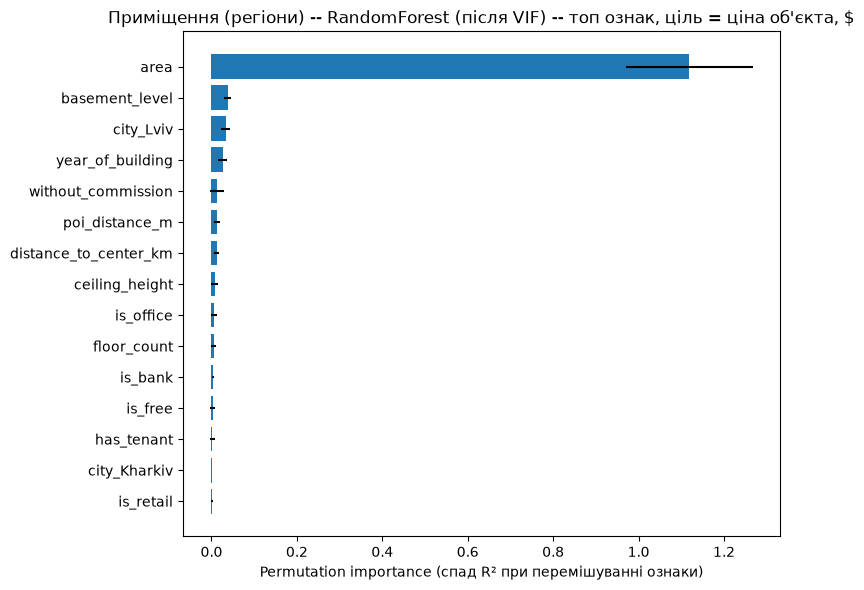

In [89]:
premises_result = train_and_compare(segments["premises"], "Приміщення (регіони)")

In [90]:
premises_result["importance_df"].head(15)

,feature,importance,std
0,area,1.118884,0.148673
1,basement_level,0.038264,0.008160
2,city_Lviv,0.033044,0.009646
3,year_of_building,0.025846,0.010672
4,without_commission,0.012954,0.016457
5,poi_distance_m,0.012820,0.005996
6,distance_to_center_km,0.012019,0.006216
7,ceiling_height,0.007409,0.008249
8,is_office,0.005690,0.007200
9,floor_count,0.005083,0.005658


In [91]:
premises_cv = cross_validate_best(
    segments["premises"], premises_result["best_name"], premises_result["kept_cols"],
    premises_result["fixed_params"],
)

  Прибрано 1 констант/малодисперсних ознак у цьому спліті: ['has_generator']
            R2         MAE_$        RMSE_$      MAPE_%
fold                                                  
1     0.471449  40606.178486  55074.009723   50.398642
2     0.455535  44110.897944  59363.679762  295.034039
3     0.712687  42251.900465  64441.128675   41.787359
4     0.488709  50176.981813  68517.705448  137.158959
5     0.419325  49930.714297  72176.146732   96.462206

--- Підсумок по фолдах ---
            R2         MAE_$        RMSE_$      MAPE_%
mean  0.509541  45415.334601  63914.534068  124.168241
std   0.116414   4413.014589   6866.328678  102.907808


In [92]:
premises_artifact = save_production_pipeline(
    segments["premises"], premises_result["best_name"], premises_result["kept_cols"],
    premises_result["fixed_params"],
    out_file="premises_model_pipeline_regions.joblib",
)

Збережено: premises_model_pipeline_regions.joblib



Гараж / паркомісце (регіони)
  Прибрано 49 констант/малодисперсних ознак у цьому спліті: ['is_bank', 'is_office', 'is_services', 'is_warehouse', 'is_production', 'is_free', 'is_retail', 'has_tenant', 'rental_price', 'implied_yield', 'has_generator', 'has_autonomous_heating', 'has_gas_boiler', 'separate_entrance', 'basement_level', 'is_exclusive', 'house_type_austrian_lux', 'house_type_belgian_project', 'house_type_czech_project', 'house_type_hostinka', 'house_type_khrushchevka', 'house_type_malosimeyka', 'house_type_polish_house', 'house_type_polish_lux', 'house_type_pre_revolutionary', 'house_type_series_87', 'house_type_series_96', 'house_type_series_kp', 'house_type_stalinka', 'wall_type_insulated_panel', 'wall_type_panel', 'city_Chernivtsi', 'city_Kropyvnytskyi', 'city_Lutsk', 'city_Mykolaiv', 'city_Poltava', 'city_Rivne', 'city_Sumy', 'city_Ternopil', 'city_Uzhhorod', 'city_Vinnytsia', 'city_Zaporizhzhia', 'city_Zhytomyr', 'ceiling_height_missing', 'year_of_building_missing', 'po

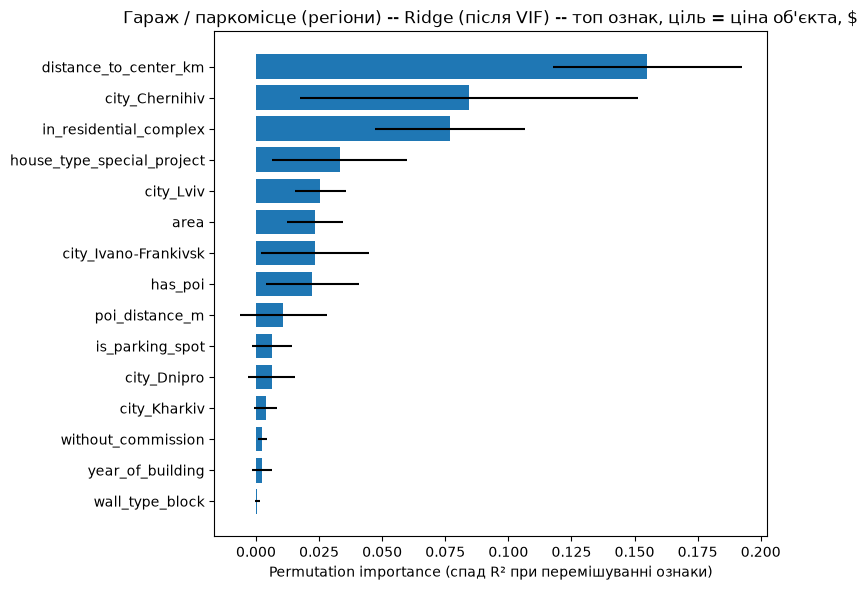

In [93]:
parking_or_garage_result = train_and_compare(segments["parking_or_garage"], "Гараж / паркомісце (регіони)")

In [94]:
parking_or_garage_result["importance_df"].head(15)

,feature,importance,std
0,distance_to_center_km,0.155021,0.037423
1,city_Chernihiv,0.084392,0.066815
2,in_residential_complex,0.076861,0.029753
3,house_type_special_project,0.033189,0.026798
4,city_Lviv,0.025515,0.010032
5,area,0.023527,0.011065
6,city_Ivano-Frankivsk,0.023508,0.021340
7,has_poi,0.022374,0.018603
8,poi_distance_m,0.010841,0.017369
9,is_parking_spot,0.006307,0.007809


In [95]:
parking_or_garage_cv = cross_validate_best(
    segments["parking_or_garage"], parking_or_garage_result["best_name"], parking_or_garage_result["kept_cols"],
    parking_or_garage_result["fixed_params"],
)

            R2        MAE_$       RMSE_$     MAPE_%
fold                                               
1     0.352064  4324.285796  5319.230373  41.864006
2     0.154775  4843.720931  6241.092875  52.380747
3     0.586275  3410.564026  4583.391526  22.735823
4     0.437834  4227.305906  5142.898970  45.766862
5     0.230462  5186.457830  6408.794977  39.716281

--- Підсумок по фолдах ---
            R2        MAE_$       RMSE_$     MAPE_%
mean  0.352282  4398.466898  5539.081744  40.492744
std   0.170236   676.374872   769.392608  11.033273


In [96]:
parking_or_garage_artifact = save_production_pipeline(
    segments["parking_or_garage"], parking_or_garage_result["best_name"], parking_or_garage_result["kept_cols"],
    parking_or_garage_result["fixed_params"],
    out_file="parking_or_garage_model_pipeline_regions.joblib",
)

Збережено: parking_or_garage_model_pipeline_regions.joblib



Склад (регіони)
  Прибрано 22 констант/малодисперсних ознак у цьому спліті: ['is_warehouse', 'is_garage', 'is_parking_spot', 'is_exclusive', 'house_type_belgian_project', 'house_type_czech_project', 'house_type_hostinka', 'house_type_malosimeyka', 'house_type_polish_house', 'house_type_polish_lux', 'house_type_pre_revolutionary', 'house_type_series_96', 'house_type_series_kp', 'city_Kropyvnytskyi', 'city_Lutsk', 'city_Mykolaiv', 'ceiling_height_missing', 'year_of_building_missing', 'poi_distance_m_missing', 'rental_price_missing', 'implied_yield_missing', 'floor_count_missing']
--- Навчання на ПОВНОМУ наборі ознак (без VIF) ---


D:\projects\apartaments-prices-analysis-new\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
27 fits failed out of a total of 135.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
27 fits failed with the following error:
Traceback (most recent call last):
  File "D:\projects\apartaments-prices-analysis-new\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "D:\projects\apartaments-prices-analysis-new\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\projects\apartaments-prices-anal


--- Результати на test (повний набір ознак) ---
                            R2         MAE_$         RMSE_$     MAPE_%
Ridge                 0.426549  76352.058619  117049.904253  71.264293
RandomForest          0.661936  64363.229862   97795.227728  54.050620
HistGradientBoosting  0.673707  62083.345856   97028.630222  53.349611

>>> Найкраща модель (за мінімальним MAPE_%): HistGradientBoosting

--- VIF-відбір (лише для feature importance, на train) ---
  Дропаю 'rental_price' (VIF=inf)
  Лишилось 51 ознак після VIF-відбору


D:\projects\apartaments-prices-analysis-new\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
27 fits failed out of a total of 135.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
27 fits failed with the following error:
Traceback (most recent call last):
  File "D:\projects\apartaments-prices-analysis-new\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "D:\projects\apartaments-prices-analysis-new\.venv\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\projects\apartaments-prices-anal


MAPE_% HistGradientBoosting: повний набір ознак = 53.3%, після VIF-відбору = 53.3% (R²: 0.674 -> 0.674)


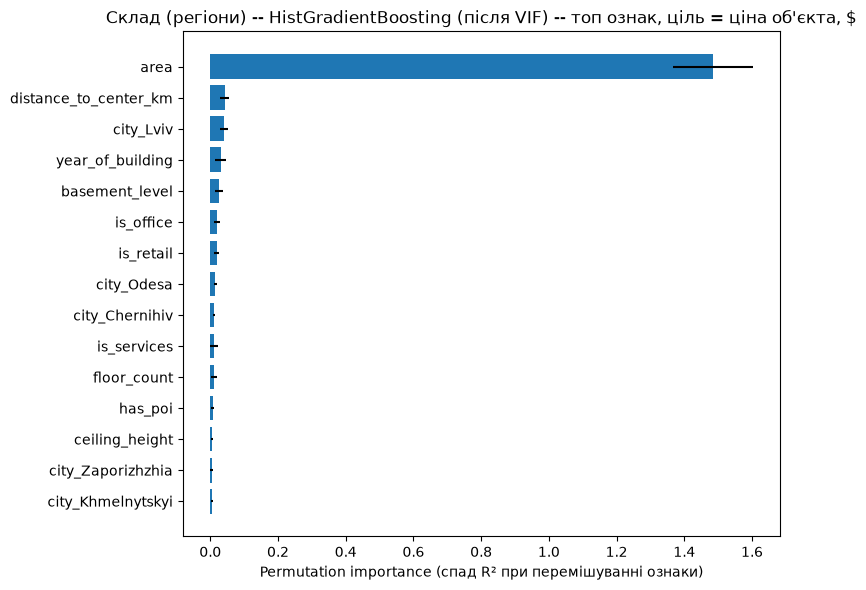

In [97]:
warehouse_result = train_and_compare(segments["warehouse"], "Склад (регіони)")

In [98]:
warehouse_result["importance_df"].head(15)

,feature,importance,std
0,area,1.484138,0.118285
1,distance_to_center_km,0.042110,0.012716
2,city_Lviv,0.040316,0.010670
3,year_of_building,0.030923,0.016243
4,basement_level,0.025483,0.011485
5,is_office,0.020422,0.008862
6,is_retail,0.018674,0.006262
7,city_Odesa,0.014471,0.004141
8,city_Chernihiv,0.012180,0.002876
9,is_services,0.011073,0.012277


In [99]:
warehouse_cv = cross_validate_best(
    segments["warehouse"], warehouse_result["best_name"], warehouse_result["kept_cols"],
    warehouse_result["fixed_params"],
)

  Прибрано 1 констант/малодисперсних ознак у цьому спліті: ['city_Sumy']
  Прибрано 2 констант/малодисперсних ознак у цьому спліті: ['wall_type_insulated_panel', 'city_Rivne']
  Прибрано 3 констант/малодисперсних ознак у цьому спліті: ['house_type_series_87', 'wall_type_insulated_panel', 'city_Rivne']
  Прибрано 1 констант/малодисперсних ознак у цьому спліті: ['wall_type_insulated_panel']
            R2         MAE_$         RMSE_$      MAPE_%
fold                                                   
1     0.673707  62083.345856   97028.630222   53.349611
2     0.674271  59989.721544   95184.403127   90.148214
3     0.667006  59912.552760   98400.185262   43.806787
4     0.594384  65536.537900  110346.097040  155.185004
5     0.641392  57548.330077   98036.717462   55.440690

--- Підсумок по фолдах ---
            R2         MAE_$        RMSE_$     MAPE_%
mean  0.650152  61014.097627  99799.206623  79.586061
std   0.033939   2994.580520   6026.463125  45.766434


In [100]:
warehouse_artifact = save_production_pipeline(
    segments["warehouse"], warehouse_result["best_name"], warehouse_result["kept_cols"],
    warehouse_result["fixed_params"],
    out_file="warehouse_model_pipeline_regions.joblib",
)

Збережено: warehouse_model_pipeline_regions.joblib
